Lade Modelle aus: C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean\models\saved_models
Metadata Keys: ['type', 'best_params', 'metrics']

XGBoost geladen: 23 Features

Berechne LSTM Predictions für Test...

Setup komplett:
  Test Rows:  168
  Zeitraum:   2024-01-23 → 2024-12-20
Backtesting Setup:
  Ticker:    AAPL
  Zeitraum:  2024-01-23 → 2024-12-20
  Test Tage: 168
  XGB Threshold: 0.5
  Scorer Threshold: 0.20

Signal Übersicht:
  Buy & Hold: 168 Trades (alle Tage)
  XGB direkt: 97 LONG Signale (57.7%)
  Scorer:     94 LONG Signale (56.0%)

                         BACKTEST ERGEBNISSE                          
Metrik                     Buy & Hold     XGB direkt     XGB+Scorer
----------------------------------------------------------------------
  Total Return                  5.06%         10.55%         11.15%
  Annual Return                 7.69%         16.24%         17.19%
  Sharpe Ratio                  0.426          1.171          1.242
  Max Drawdown               

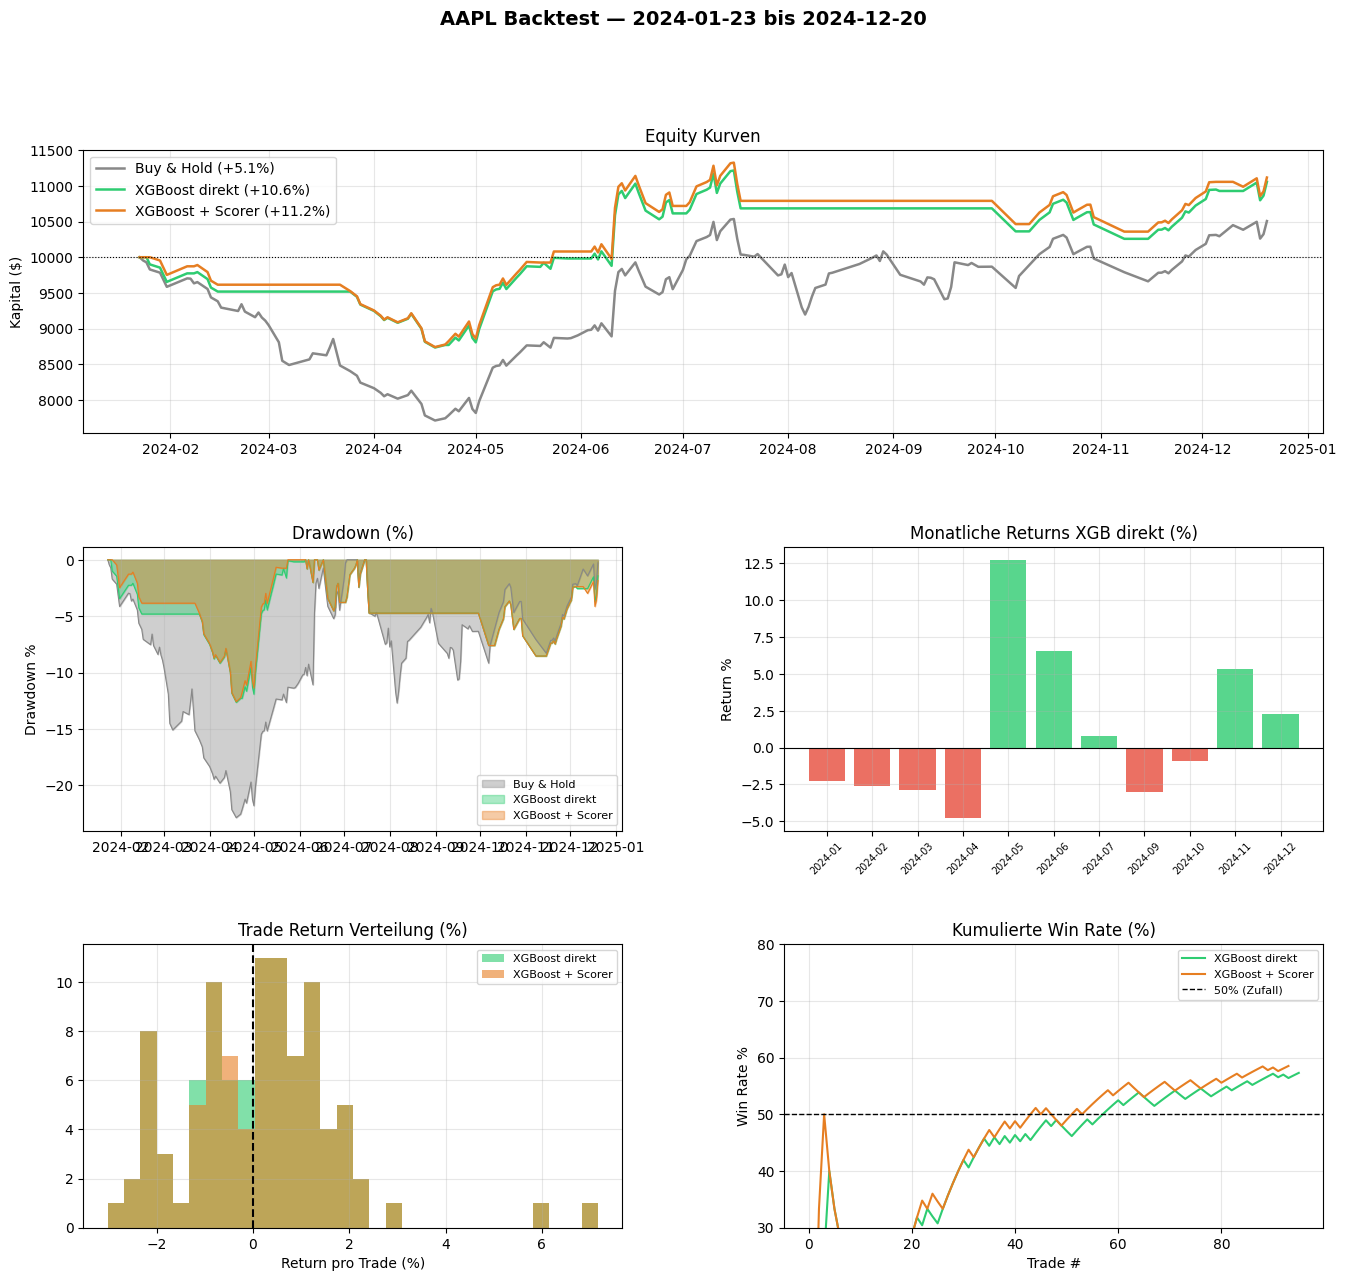


Backtest gespeichert: C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean\models\saved_models\confidence_scorer\backtest_results.png
Summary JSON: C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean\models\saved_models\confidence_scorer\backtest_summary.json


In [5]:
# ==========================================
# Notebook 03: Backtesting & Evaluation
# ==========================================
# Vergleicht 3 Strategien:
#
#   Strategy 0: Buy & Hold (Benchmark)
#   Strategy 1: XGBoost direkt (alle Tage, 60.12% Accuracy)
#   Strategy 2: XGBoost + Scorer Filter (nur hohe Confidence)
#
# Metriken:
#   Total Return, Annualized Return, Sharpe Ratio,
#   Max Drawdown, Win Rate, Profit Factor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from pathlib import Path

# ==========================================
# Setup — alles wird aus gespeicherten Dateien geladen
# Kein Notebook 02 Kernel nötig
# ==========================================
import xgboost as xgb
from sklearn.preprocessing import RobustScaler

# ---- Pfade anpassen ----
PROJECT_ROOT = Path(r"C:\Users\jamin\Desktop\Coding\Projects\StockVision-clean")
TICKER       = "AAPL"

MODELS_DIR   = PROJECT_ROOT / "models" / "saved_models"
PRICE_DIR    = MODELS_DIR / "lstm_price"
CLF_DIR      = MODELS_DIR / "xgb_classifier"
SCORER_DIR   = MODELS_DIR / "confidence_scorer"
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

print(f"Lade Modelle aus: {MODELS_DIR}")

# ---- XGBoost Modell laden ----
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(str(CLF_DIR / "model.json"))

clf_meta      = json.loads((CLF_DIR / "metadata.json").read_text())
print(f"Metadata Keys: {list(clf_meta.keys())}")

# ---- Test-Daten laden ----
feat_full = pd.read_csv(
    DATA_DIR / f"{TICKER}_features_stationary.csv",
    index_col=0, parse_dates=True
)
meta      = json.loads((DATA_DIR / f"{TICKER}_meta.json").read_text())
feature_cols_lstm = meta["feature_cols"]

# 5-Tage Forward Return Target (identisch mit v2a Final)
feat_full["Return_5d_fwd"] = feat_full["Close"].pct_change(5).shift(-5)
feat_full = feat_full.replace([np.inf, -np.inf], np.nan).dropna(subset=["Return_5d_fwd"]).copy()

n_total   = len(feat_full)
train_end = int(n_total * 0.70)
val_end   = int(n_total * 0.85)

train_returns = feat_full.iloc[:train_end]["Return_5d_fwd"]
q_low  = train_returns.quantile(0.35)
q_high = train_returns.quantile(0.65)

feat_full["Target"] = np.where(
    feat_full["Return_5d_fwd"] <= q_low,  0,
    np.where(feat_full["Return_5d_fwd"] >= q_high, 1, -1))
feat_full = feat_full[feat_full["Target"] != -1].copy()

n2 = len(feat_full)
te2 = int(n2 * 0.70)
ve2 = int(n2 * 0.85)

test_xgb = feat_full.iloc[ve2:].copy()
train_xgb_raw = feat_full.iloc[:te2].copy()

# LSTM Predictions für Test berechnen
import pickle, tensorflow as tf
from tensorflow import keras

with open(PRICE_DIR / "scaler.pkl", "rb") as f:
    scaler_data = pickle.load(f)

feature_scaler = scaler_data["feature_scaler"]
LOOKBACK       = scaler_data["lookback"]
return_std     = scaler_data["return_std"]

# XGBoost Feature-Liste = LSTM Features + lstm_pred_return
xgb_feat_cols  = feature_cols_lstm + ["lstm_pred_return"]
print(f"XGBoost geladen: {len(xgb_feat_cols)} Features")

# Custom Loss laden
def directional_loss(y_true, y_pred):
    mse         = tf.reduce_mean(tf.square(y_true - y_pred))
    directional = tf.reduce_mean(tf.maximum(0.0, 1.0 - y_true * y_pred))
    return 0.5 * mse + 0.5 * directional

lstm_model = keras.models.load_model(
    PRICE_DIR / "model.keras",
    custom_objects={"directional_loss": directional_loss}
)

def get_lstm_preds(split_df, scaler, feature_cols, lookback, return_std, model):
    X_scaled = scaler.transform(split_df[feature_cols])
    X_seq, indices = [], []
    for i in range(lookback, len(split_df)):
        X_seq.append(X_scaled[i - lookback:i])
        indices.append(split_df.index[i])
    if not X_seq:
        return pd.Series(dtype=float)
    preds = model.predict(np.asarray(X_seq, dtype=np.float32), verbose=0).reshape(-1)
    return pd.Series(preds * return_std, index=indices, name="lstm_pred_return")

print("Berechne LSTM Predictions für Test...")
lp_te = get_lstm_preds(test_xgb, feature_scaler, feature_cols_lstm, LOOKBACK, return_std, lstm_model)
test_xgb = test_xgb.loc[lp_te.index].copy()
test_xgb["lstm_pred_return"] = lp_te

X_test_xgb = test_xgb[xgb_feat_cols].values
y_test_xgb = test_xgb["Target"].values.astype(int)

# ---- XGBoost Predictions ----
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

# ---- Scorer Predictions ----
scorer_path = SCORER_DIR / "test_predictions.csv"
scorer_cfg  = json.loads((SCORER_DIR / "config.json").read_text())
scorer_df   = pd.read_csv(scorer_path, index_col="date", parse_dates=True)
THRESHOLD   = scorer_cfg["threshold"]

print(f"\nSetup komplett:")
print(f"  Test Rows:  {len(test_xgb)}")
print(f"  Zeitraum:   {test_xgb.index[0].date()} → {test_xgb.index[-1].date()}")

print(f"Backtesting Setup:")
print(f"  Ticker:    {TICKER}")
print(f"  Zeitraum:  {test_xgb.index[0].date()} → {test_xgb.index[-1].date()}")
print(f"  Test Tage: {len(test_xgb)}")
print(f"  XGB Threshold: 0.5")
print(f"  Scorer Threshold: {THRESHOLD:.2f}")

# ==========================================
# Backtest Engine
# ==========================================
def run_backtest(
    dates:       pd.DatetimeIndex,
    close:       np.ndarray,
    next_close:  np.ndarray,
    signals:     np.ndarray,   # +1 = LONG, 0 = SKIP, -1 = SHORT (nur Long hier)
    initial_capital: float = 10_000.0,
    long_only:   bool = True,
    transaction_cost: float = 0.001,  # 0.1% pro Trade (Spread + Gebühr)
    name:        str  = "Strategy",
) -> dict:
    """
    Einfacher täglicher Backtest.
    Signal = +1: kaufe am Close, verkaufe am nächsten Close
    Signal = 0:  kein Trade, Cash hält
    """
    capital    = initial_capital
    equity     = [capital]
    trades     = []
    in_trade   = False

    for i in range(len(signals) - 1):
        sig = signals[i]

        if sig == 1:  # LONG
            entry  = close[i]
            exit_  = next_close[i]
            ret    = (exit_ - entry) / entry - transaction_cost
            pnl    = capital * ret
            capital += pnl
            trades.append({
                "date":      dates[i],
                "direction": "LONG",
                "entry":     entry,
                "exit":      exit_,
                "return":    ret,
                "pnl":       pnl,
                "correct":   ret > 0,
            })
        elif sig == -1 and not long_only:  # SHORT
            entry  = close[i]
            exit_  = next_close[i]
            ret    = (entry - exit_) / entry - transaction_cost
            pnl    = capital * ret
            capital += pnl
            trades.append({
                "date":      dates[i],
                "direction": "SHORT",
                "entry":     entry,
                "exit":      exit_,
                "return":    ret,
                "pnl":       pnl,
                "correct":   ret > 0,
            })

        equity.append(capital)

    equity     = np.array(equity[:len(signals)])
    trades_df  = pd.DataFrame(trades) if trades else pd.DataFrame()

    # ==========================================
    # Performance Metriken
    # ==========================================
    total_return    = (equity[-1] - initial_capital) / initial_capital
    n_days          = len(signals)
    n_years         = n_days / 252
    annual_return   = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0

    # Tägliche Returns der Strategie
    daily_returns   = np.diff(equity) / equity[:-1]
    daily_returns   = daily_returns[daily_returns != 0]  # nur Trade-Tage

    sharpe = 0.0
    if len(daily_returns) > 1 and daily_returns.std() > 0:
        sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)

    # Max Drawdown
    peak       = np.maximum.accumulate(equity)
    drawdown   = (equity - peak) / peak
    max_dd     = float(drawdown.min())

    # Win Rate & Profit Factor
    if len(trades_df) > 0:
        win_rate     = trades_df["correct"].mean()
        wins         = trades_df[trades_df["pnl"] > 0]["pnl"].sum()
        losses       = abs(trades_df[trades_df["pnl"] < 0]["pnl"].sum())
        profit_factor = wins / losses if losses > 0 else float("inf")
        n_trades     = len(trades_df)
    else:
        win_rate = profit_factor = n_trades = 0

    return {
        "name":           name,
        "equity":         equity,
        "trades":         trades_df,
        "drawdown":       drawdown,
        "total_return":   total_return,
        "annual_return":  annual_return,
        "sharpe":         sharpe,
        "max_drawdown":   max_dd,
        "win_rate":       win_rate,
        "profit_factor":  profit_factor,
        "n_trades":       n_trades,
        "final_capital":  float(equity[-1]),
    }


# ==========================================
# Daten vorbereiten
# ==========================================
dates      = pd.to_datetime(test_xgb.index)
close      = test_xgb["Close"].values.astype(float)
next_close = test_xgb["Next_Close"].values.astype(float)
n          = len(dates)

# Strategy 0: Buy & Hold
sig_bh = np.ones(n, dtype=int)

# Strategy 1: XGBoost direkt
# 1 = UP predicted -> LONG, 0 = DOWN -> SKIP (long-only)
sig_xgb = y_pred_xgb.astype(int)

# Strategy 2: Scorer Filter
# Trade nur wenn score >= threshold UND direction == UP
sig_scorer = np.zeros(n, dtype=int)
for i, date in enumerate(dates):
    if date in scorer_df.index:
        row = scorer_df.loc[date]
        if row["trade"] and row["direction"] == 1:
            sig_scorer[i] = 1

print(f"\nSignal Übersicht:")
print(f"  Buy & Hold: {sig_bh.sum()} Trades (alle Tage)")
print(f"  XGB direkt: {sig_xgb.sum()} LONG Signale ({sig_xgb.sum()/n:.1%})")
print(f"  Scorer:     {sig_scorer.sum()} LONG Signale ({sig_scorer.sum()/n:.1%})")

# ==========================================
# Backtests laufen lassen
# ==========================================
INITIAL_CAPITAL  = 10_000.0
TRANSACTION_COST = 0.001   # 0.1%

bt_bh     = run_backtest(dates, close, next_close, sig_bh,
                          INITIAL_CAPITAL, name="Buy & Hold")
bt_xgb    = run_backtest(dates, close, next_close, sig_xgb,
                          INITIAL_CAPITAL, name="XGBoost direkt")
bt_scorer = run_backtest(dates, close, next_close, sig_scorer,
                          INITIAL_CAPITAL, name="XGBoost + Scorer")

results = [bt_bh, bt_xgb, bt_scorer]

# ==========================================
# Performance Tabelle
# ==========================================
print("\n" + "="*70)
print(f"{'BACKTEST ERGEBNISSE':^70}")
print("="*70)
print(f"{'Metrik':<22} {'Buy & Hold':>14} {'XGB direkt':>14} {'XGB+Scorer':>14}")
print("-"*70)

metrics = [
    ("Total Return",    "total_return",   "{:.2%}"),
    ("Annual Return",   "annual_return",  "{:.2%}"),
    ("Sharpe Ratio",    "sharpe",         "{:.3f}"),
    ("Max Drawdown",    "max_drawdown",   "{:.2%}"),
    ("Win Rate",        "win_rate",       "{:.2%}"),
    ("Profit Factor",   "profit_factor",  "{:.3f}"),
    ("# Trades",        "n_trades",       "{:.0f}"),
    ("Final Capital",   "final_capital",  "${:.2f}"),
]

for label, key, fmt in metrics:
    vals = [fmt.format(r[key]) for r in results]
    print(f"  {label:<20} {vals[0]:>14} {vals[1]:>14} {vals[2]:>14}")

print("="*70)

# Gewinner pro Metrik
best_return  = max(results, key=lambda x: x["total_return"])["name"]
best_sharpe  = max(results, key=lambda x: x["sharpe"])["name"]
best_dd      = max(results, key=lambda x: x["max_drawdown"])["name"]
print(f"\n  Bester Total Return:  {best_return}")
print(f"  Bester Sharpe Ratio:  {best_sharpe}")
print(f"  Kleinstes Drawdown:   {best_dd}")

# ==========================================
# Plots
# ==========================================
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle(f"{TICKER} Backtest — {dates[0].date()} bis {dates[-1].date()}",
             fontsize=14, fontweight="bold")

colors = {"Buy & Hold": "#888888", "XGBoost direkt": "#2ecc71", "XGBoost + Scorer": "#e67e22"}

# Plot 1: Equity Kurven
ax1 = fig.add_subplot(gs[0, :])
for bt in results:
    ax1.plot(dates[:len(bt["equity"])], bt["equity"],
             label=f"{bt['name']} ({bt['total_return']:+.1%})",
             linewidth=1.8, color=colors[bt["name"]])
ax1.axhline(INITIAL_CAPITAL, color="black", linestyle=":", linewidth=0.8)
ax1.set_title("Equity Kurven")
ax1.set_ylabel("Kapital ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Drawdown
ax2 = fig.add_subplot(gs[1, 0])
for bt in results:
    ax2.fill_between(dates[:len(bt["drawdown"])], bt["drawdown"] * 100, 0,
                     alpha=0.4, color=colors[bt["name"]], label=bt["name"])
    ax2.plot(dates[:len(bt["drawdown"])], bt["drawdown"] * 100,
             linewidth=0.8, color=colors[bt["name"]])
ax2.set_title("Drawdown (%)")
ax2.set_ylabel("Drawdown %")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Monatliche Returns Heatmap (XGB direkt)
ax3 = fig.add_subplot(gs[1, 1])
if len(bt_xgb["trades"]) > 0:
    trades_xgb = bt_xgb["trades"].copy()
    trades_xgb["month"] = trades_xgb["date"].dt.to_period("M")
    monthly = trades_xgb.groupby("month")["return"].sum()
    monthly_vals = monthly.values * 100
    months_labels = [str(m) for m in monthly.index]
    bar_colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in monthly_vals]
    ax3.bar(range(len(monthly_vals)), monthly_vals, color=bar_colors, alpha=0.8)
    ax3.set_xticks(range(0, len(months_labels), max(1, len(months_labels)//6)))
    ax3.set_xticklabels(months_labels[::max(1, len(months_labels)//6)], rotation=45, fontsize=7)
    ax3.axhline(0, color="black", linewidth=0.8)
    ax3.set_title("Monatliche Returns XGB direkt (%)")
    ax3.set_ylabel("Return %")
    ax3.grid(True, alpha=0.3)

# Plot 4: Trade Return Distribution
ax4 = fig.add_subplot(gs[2, 0])
for bt in [bt_xgb, bt_scorer]:
    if len(bt["trades"]) > 0:
        ax4.hist(bt["trades"]["return"] * 100, bins=30, alpha=0.6,
                 label=bt["name"], color=colors[bt["name"]])
ax4.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax4.set_title("Trade Return Verteilung (%)")
ax4.set_xlabel("Return pro Trade (%)")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# Plot 5: Kumulativer Win Rate über Zeit
ax5 = fig.add_subplot(gs[2, 1])
for bt in [bt_xgb, bt_scorer]:
    if len(bt["trades"]) > 0:
        cum_wr = bt["trades"]["correct"].expanding().mean()
        ax5.plot(range(len(cum_wr)), cum_wr * 100,
                 label=bt["name"], linewidth=1.5, color=colors[bt["name"]])
ax5.axhline(50, color="black", linestyle="--", linewidth=1, label="50% (Zufall)")
ax5.set_title("Kumulierte Win Rate (%)")
ax5.set_xlabel("Trade #")
ax5.set_ylabel("Win Rate %")
ax5.set_ylim(30, 80)
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

plt.savefig(str(SCORER_DIR / "backtest_results.png"), dpi=150, bbox_inches="tight")
plt.show()

# ==========================================
# Speichern
# ==========================================
backtest_summary = {
    "ticker":     TICKER,
    "period":     f"{dates[0].date()} to {dates[-1].date()}",
    "strategies": {
        bt["name"]: {
            "total_return":  bt["total_return"],
            "annual_return": bt["annual_return"],
            "sharpe":        bt["sharpe"],
            "max_drawdown":  bt["max_drawdown"],
            "win_rate":      bt["win_rate"],
            "profit_factor": bt["profit_factor"],
            "n_trades":      bt["n_trades"],
        }
        for bt in results
    }
}
(SCORER_DIR / "backtest_summary.json").write_text(
    json.dumps(backtest_summary, indent=2), encoding="utf-8")

print(f"\nBacktest gespeichert: {SCORER_DIR / 'backtest_results.png'}")
print(f"Summary JSON: {SCORER_DIR / 'backtest_summary.json'}")